## EDA and Visualization
### Charts
- Mean weekly flight price vs sum of the week's google trends' interest score (Line graph)
- Mean flight price per days to festival (Scatterplot)
- Min flight price per days to festival (Scatterplot)
- Mean weekly hotel price vs sum of the week's google trends' interest score (Line graph)
- Mean hotel price per days to festival (Scatterplot)
- Min hotel price per days to festival (Scatterplot)
- Weekly rolling baseline flight prices vs weekly target dateline flight prices  difference (Line graph)
- Weekly rolling baseline hotel prices vs weekly target dateline weekly hotel prices  difference (Line graph)

In [342]:
import pandas as pd
from pathlib import Path

df = pd.DataFrame()

df = pd.read_csv('../data/processed/masskara/analysis/master.csv')

df.head(1)

,date_collected,trend_search_score,flight_fest_min_price,flight_fest_max_price,flight_fest_median_price,flight_fest_mean_price,flight_fest_quote_count,flight_rolling_min_price,flight_rolling_max_price,flight_rolling_median_price,...,hotel_rolling_quote_count,flight_price_premium,hotel_price_premium,trend_velocity_7d,trend_score_lag_1d,trend_score_lag_2d,trend_score_lag_3d,flight_median_change_1d,hotel_median_change_1d,days_to_festival
0,2026-09-02,82,1936,2731,2234.0,2317.230769,13,2900,5643,3684.0,...,20,0.606406,1.122834,NaN,NaN,NaN,NaN,NaN,NaN,37


In [343]:
# convert date from str to datetime
# display(df.dtypes)
df['date_collected'] = pd.to_datetime(df['date_collected'])
# display(df.dtypes)

In [344]:
# resample to weekly
weekly_df = df.set_index('date_collected').resample('W').agg({
    'trend_search_score':'sum',
    'flight_fest_mean_price':'mean',
    'flight_fest_min_price':'mean',
    'flight_rolling_mean_price':'mean',
    'days_to_festival':'min',
    'hotel_fest_mean_price':'mean',
    'hotel_fest_min_price':'mean',
    'hotel_rolling_mean_price':'mean'

}).reset_index()

# custom tag
weekly_df['combined_yAxisTitle'] = weekly_df['date_collected'].astype(str) + " \n(" + weekly_df['days_to_festival'].astype(str) + ") days to festival"

# price difference
# weekly_df['flight_price_diff_rolling_v_target'] = weekly_df['flight_rolling_mean_price'] - weekly_df['flight_fest_mean_price']
# weekly_df['hotel_price_diff_rolling_v_target'] = weekly_df['hotel_rolling_mean_price'] - weekly_df['hotel_fest_mean_price']

In [345]:
weekly_df

,date_collected,trend_search_score,flight_fest_mean_price,flight_fest_min_price,flight_rolling_mean_price,days_to_festival,hotel_fest_mean_price,hotel_fest_min_price,hotel_rolling_mean_price,combined_yAxisTitle
0,2026-09-06,297,2373.661538,1917.600000,4330.901958,33,2393.104737,815.200000,2201.305000,2026-09-06 \n(33) days to festival
1,2026-09-13,415,2691.615385,1922.000000,3631.758730,26,2449.942857,880.000000,2147.185714,2026-09-13 \n(26) days to festival
2,2026-09-20,370,2908.318681,1973.000000,5040.390590,19,2541.390602,845.571429,2281.835714,2026-09-20 \n(19) days to festival
3,2026-09-27,463,3113.417582,2092.142857,7678.614286,12,2490.050794,1068.428571,2168.751462,2026-09-27 \n(12) days to festival
4,2026-10-04,90,3375.307692,2583.000000,3814.750000,11,2745.050000,1415.000000,2578.058824,2026-10-04 \n(11) days to festival


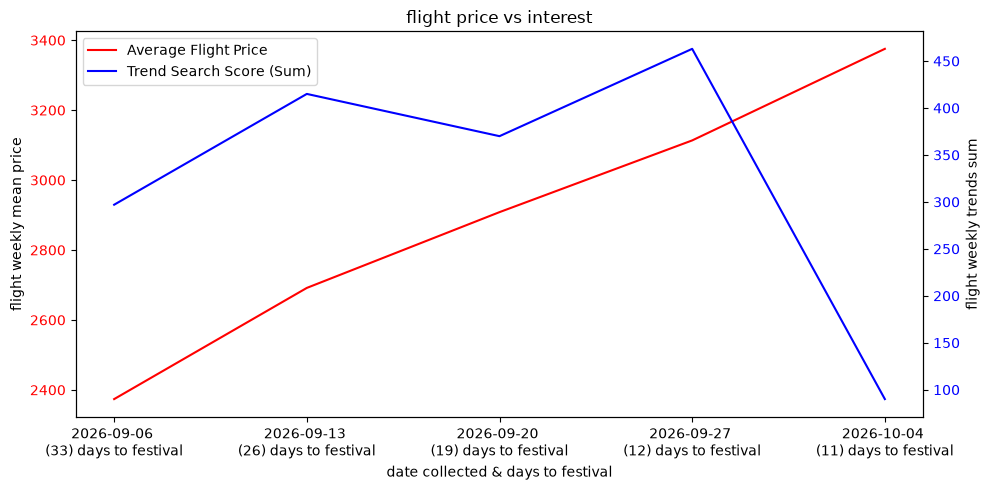

In [346]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_fest_mean_price'], 
    label='Average Flight Price', 
    color='red')
ax1.set_xlabel('date collected & days to festival')
ax1.set_ylabel('flight weekly mean price')
ax1.tick_params(axis='y', labelcolor='red')
# ax1.set_yinverted(True)

ax2 = ax1.twinx()

line2 = ax2.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['trend_search_score'],
    label='Trend Search Score (Sum)',
    color='blue')
ax2.set_ylabel('flight weekly trends sum')
ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('flight price vs interest')
fig.tight_layout()
plt.show()

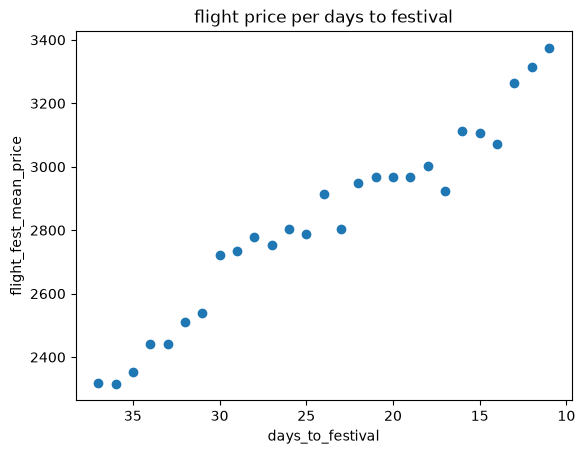

In [347]:
plt.scatter(df['days_to_festival'], df['flight_fest_mean_price'])

plt.title("flight price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("flight_fest_mean_price")

plt.gca().invert_xaxis()
plt.show()

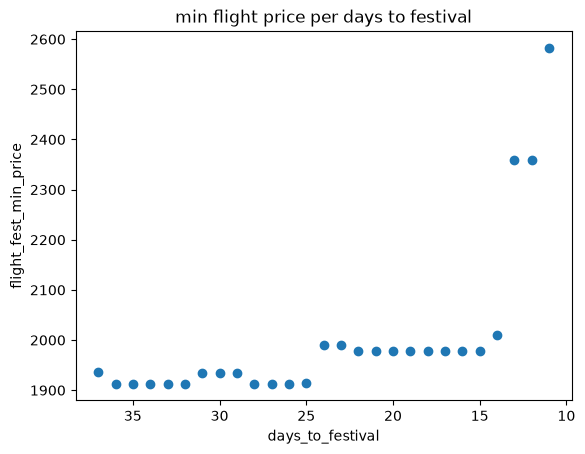

In [348]:
plt.scatter(df['days_to_festival'], df['flight_fest_min_price'])

plt.title("min flight price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("flight_fest_min_price")

plt.gca().invert_xaxis()
plt.show()

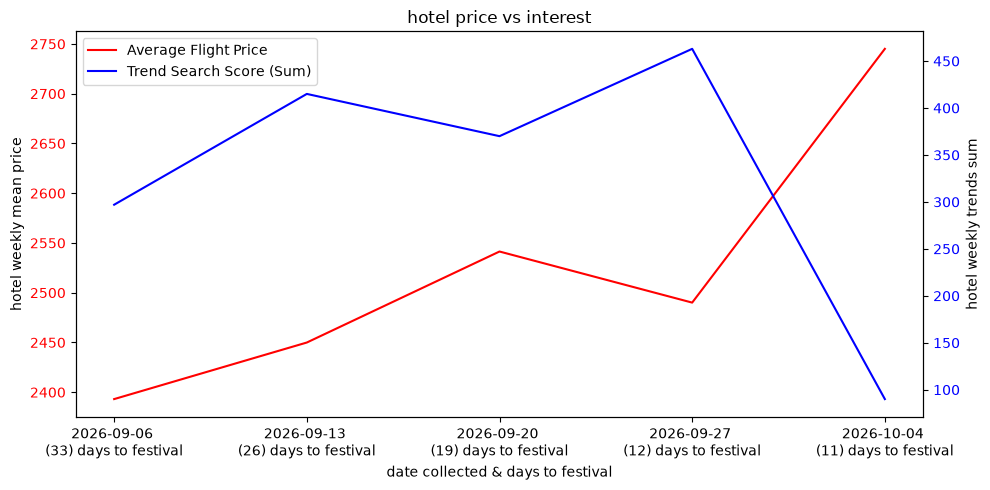

In [349]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_fest_mean_price'], 
    label='Average Flight Price', 
    color='red')
ax1.set_xlabel('date collected & days to festival')
ax1.set_ylabel('hotel weekly mean price')
ax1.tick_params(axis='y', labelcolor='red')
# ax1.set_yinverted(True)

ax2 = ax1.twinx()

line2 = ax2.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['trend_search_score'],
    label='Trend Search Score (Sum)',
    color='blue')
ax2.set_ylabel('hotel weekly trends sum')
ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('hotel price vs interest')
fig.tight_layout()
plt.show()

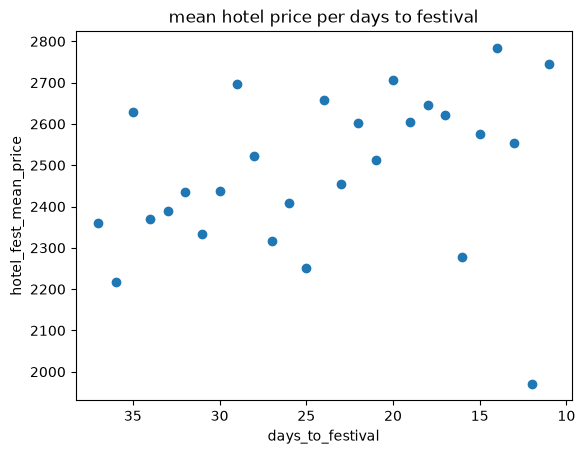

In [350]:
plt.scatter(df['days_to_festival'], df['hotel_fest_mean_price'])

plt.title("mean hotel price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("hotel_fest_mean_price")

plt.gca().invert_xaxis()
plt.show()

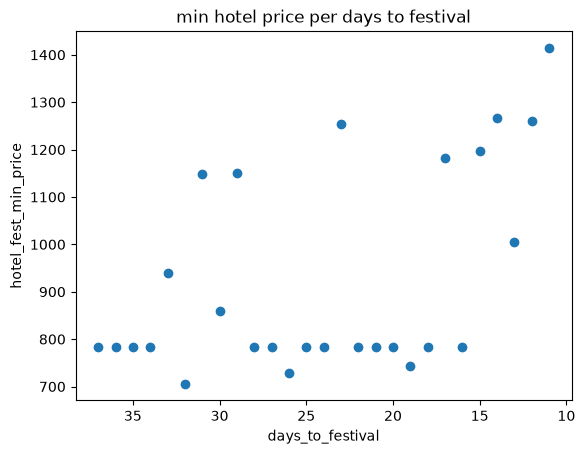

In [351]:
plt.scatter(df['days_to_festival'], df['hotel_fest_min_price'])

plt.title("min hotel price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("hotel_fest_min_price")

plt.gca().invert_xaxis()
plt.show()

#### Trends as festival gets closer

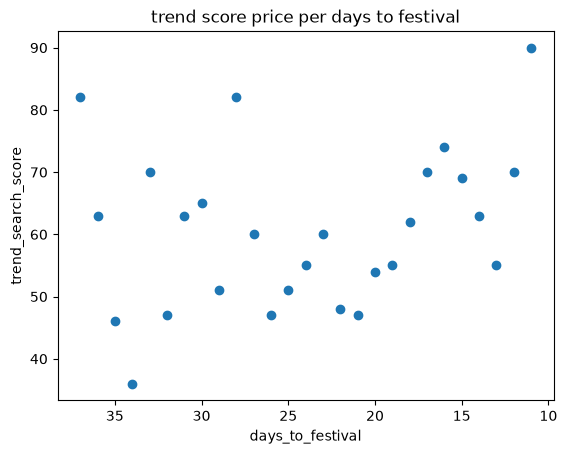

In [352]:
plt.scatter(df['days_to_festival'], df['trend_search_score'])

plt.title("trend score price per days to festival")
plt.xlabel("days_to_festival")
plt.ylabel("trend_search_score")

plt.gca().invert_xaxis()
plt.show()

#### Rolling vs Target date price

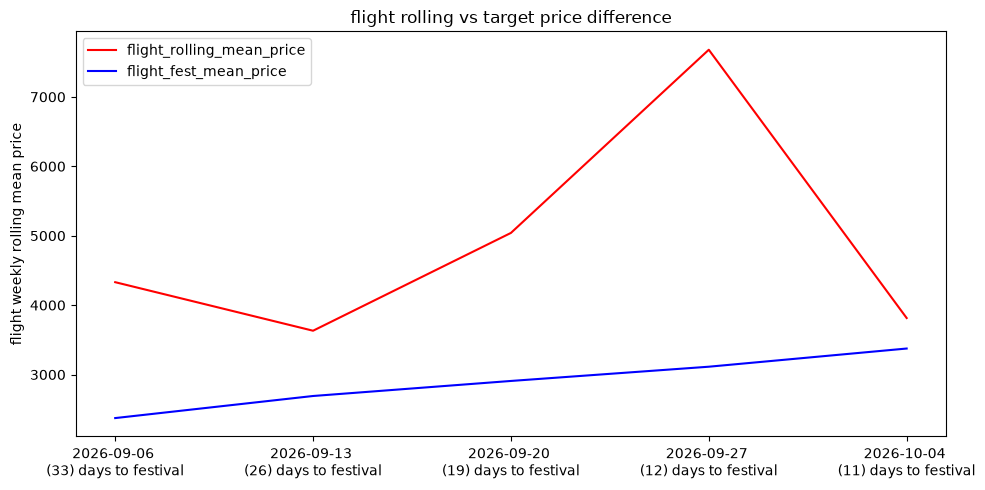

In [355]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_rolling_mean_price'], 
    label='flight_rolling_mean_price', 
    color='red')
ax1.set_ylabel('flight weekly rolling mean price')
ax1.tick_params(axis='y')
# ax1.set_yinverted(True)


line2 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['flight_fest_mean_price'],
    label='flight_fest_mean_price',
    color='blue')
ax1.tick_params(axis='y')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('flight rolling vs target price difference')
fig.tight_layout()
plt.show()

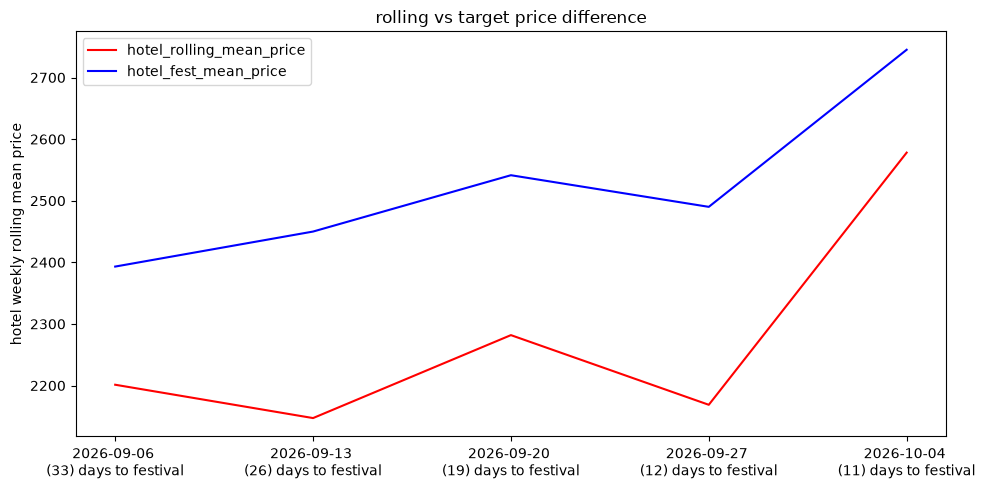

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# plotting two y axises

line1 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_rolling_mean_price'], 
    label='hotel_rolling_mean_price', 
    color='red')
ax1.set_ylabel('hotel weekly rolling mean price')
ax1.tick_params(axis='y')
# ax1.set_yinverted(True)


line2 = ax1.plot(
    weekly_df['combined_yAxisTitle'], 
    weekly_df['hotel_fest_mean_price'],
    label='hotel_fest_mean_price',
    color='blue')
ax1.tick_params(axis='y')
# ax2.set_yinverted(True)

# combining the lines

lines = line1 + line2

labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# showing what we got

plt.title('hotel rolling vs target price difference')
fig.tight_layout()
plt.show()